In [188]:
import backtrader as bt
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Pull historical data using yfinance or investpy for PSE stocks, or your existing forex data

In [190]:
# Download EUR/USD historical data
dt = yf.download('EUR=X', start='2020-01-01', end='2026-01-01', interval='1d')
dt.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,EUR=X,EUR=X,EUR=X,EUR=X,EUR=X
2020-01-01,0.891200,0.89610,0.8906,0.89120,0
2020-01-02,0.891200,0.89551,0.8907,0.89135,0
2020-01-03,0.895140,0.89882,0.8944,0.89519,0
2020-01-06,0.895900,0.89621,0.8922,0.89586,0
2020-01-07,0.893017,0.89808,0.8929,0.89319,0


### 2. Compute the signals: for SMA crossover, `df['SMA50'] = df['Close'].rolling(50).mean()`

In [192]:
# Getting the simple moving average (SMA) closing prices of EUR/USD from past 50 and 200 prices
dt['SMA50'] = dt['Close'].rolling(50).mean()
dt['SMA200'] = dt['Close'].rolling(200).mean()

dt.tail()

Price,Close,High,Low,Open,Volume,SMA50,SMA200
Ticker,EUR=X,EUR=X,EUR=X,EUR=X,EUR=X,,
2025-12-24,0.84778,0.84931,0.84680,0.84777,0,0.860300,0.868852
2025-12-26,0.84851,0.85012,0.84750,0.84862,0,0.860098,0.868515
2025-12-29,0.84942,0.85077,0.84828,0.84926,0,0.859992,0.868192
2025-12-30,0.84941,0.85134,0.84880,0.84940,0,0.859823,0.867857
2025-12-31,0.85126,0.85318,0.85043,0.85132,0,0.859673,0.867508


### 3. Generate a position column: 1 when long, 0 otherwise

In [194]:
# Long when the 50-day SMA crosses above the 200-day SMA, exit when it crosses back
position_condition = dt['SMA50'] > dt['SMA200']
dt['Position'] = np.where(position_condition, 1, 0)

dt.tail()

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Position
Ticker,EUR=X,EUR=X,EUR=X,EUR=X,EUR=X,,,
2025-12-24,0.84778,0.84931,0.84680,0.84777,0,0.860300,0.868852,0
2025-12-26,0.84851,0.85012,0.84750,0.84862,0,0.860098,0.868515,0
2025-12-29,0.84942,0.85077,0.84828,0.84926,0,0.859992,0.868192,0
2025-12-30,0.84941,0.85134,0.84880,0.84940,0,0.859823,0.867857,0
2025-12-31,0.85126,0.85318,0.85043,0.85132,0,0.859673,0.867508,0


### 4. Compute strategy returns: `df['Strategy_Return'] = df['Position'].shift(1) * df['Daily_Return']`
The `.shift(1)` is critical — it prevents look-ahead bias (using tomorrow's signal to trade today)

In [196]:
dt['Daily_Return'] = np.log(dt['Close'] / dt['Close'].shift(1)).fillna(0)
dt['Strategy_Return'] = dt['Position'].shift(1) * dt['Daily_Return']

# Clean up the very first row's NaN resulting from the shift
dt['Strategy_Return'] = dt['Strategy_Return'].fillna(0)

dt.tail()

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Position,Daily_Return,Strategy_Return
Ticker,EUR=X,EUR=X,EUR=X,EUR=X,EUR=X,,,,,
2025-12-24,0.84778,0.84931,0.84680,0.84777,0,0.860300,0.868852,0,-0.002509,-0.0
2025-12-26,0.84851,0.85012,0.84750,0.84862,0,0.860098,0.868515,0,0.000861,0.0
2025-12-29,0.84942,0.85077,0.84828,0.84926,0,0.859992,0.868192,0,0.001072,0.0
2025-12-30,0.84941,0.85134,0.84880,0.84940,0,0.859823,0.867857,0,-0.000012,-0.0
2025-12-31,0.85126,0.85318,0.85043,0.85132,0,0.859673,0.867508,0,0.002176,0.0


### 6. Compute and plot: cumulative returns of strategy vs. buy-and-hold benchmark

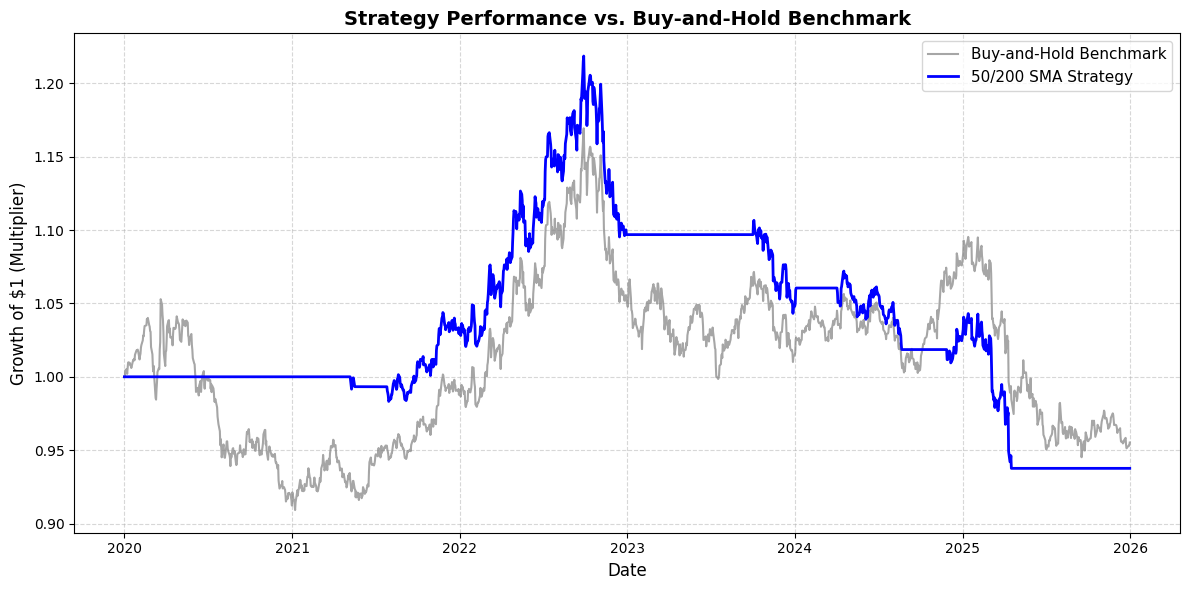

In [198]:
# Cumulative sum of log returns
cumulative_log_returns = dt['Strategy_Return'].cumsum()

# Converting log returns to percentage
dt['Cumulative_Return'] = np.exp(cumulative_log_returns)

# 1. Compute Benchmark Cumulative Return (holding the asset 100% of the time)
# We take the cumulative sum of the raw daily returns and exponentiate it
dt['Benchmark_Cum_Return'] = np.exp(dt['Daily_Return'].cumsum())

# 2. Compute Strategy Cumulative Return 
dt['Strategy_Cum_Return'] = np.exp(dt['Strategy_Return'].cumsum())

# 3. Plotting the Comparison
plt.figure(figsize=(12, 6))

# Plot both lines
plt.plot(dt.index, dt['Benchmark_Cum_Return'], label='Buy-and-Hold Benchmark', color='gray', alpha=0.7, lw=1.5)
plt.plot(dt.index, dt['Strategy_Cum_Return'], label='50/200 SMA Strategy', color='blue', lw=2)

# Format the chart beautifully
plt.title('Strategy Performance vs. Buy-and-Hold Benchmark', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Growth of $1 (Multiplier)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Ensure layout fits cleanly
plt.tight_layout()
plt.show()

### 7. Report: Total Return, Sharpe Ratio, Max Drawdown, Win Rate, number of trades

In [211]:
# Total return
total_return = np.exp(dt['Strategy_Return'].sum()) - 1


# Sharpe Ratio
mean_return = dt['Strategy_Return'].mean()
volatility = dt['Strategy_Return'].std()

annualized_return = mean_return * 252
annualized_vol = volatility * np.sqrt(252)

rf = 0.01933 # Euro Short-Term Rate - https://www.ecb.europa.eu/stats/financial_markets_and_interest_rates/euro_short-term_rate/html/index.en.html
sharpe = (annualized_return - rf) / annualized_vol


# MDD
equity_curve = np.exp(dt['Strategy_Return'].cumsum())

# Compute the running peak
peaks = equity_curve.cummax()

# Compute the drawdown percentage
drawdowns = (equity_curve - peaks) / peaks

# Extract the worst (minimum) drawdown value
max_drawdown = drawdowns.min() * 100


# Win Rate
# .diff() shows where Position shifts from 0 to 1, or 1 to 0
dt['Trade_Signal'] = dt['Position'].diff()

# Grouping rows that belong to the same active trade window
dt['Trade_ID'] = (dt['Trade_Signal'] != 0).cumsum()

# Filter for rows where you actually hold a position (Position == 1)
active_trades = dt[dt['Position'] == 1]

# We sum the log returns for each trade window, then exponentiate
trade_performance = active_trades.groupby('Trade_ID')['Daily_Return'].sum().apply(np.exp) - 1

num_trades = len(trade_performance)
winning_trades = (trade_performance > 0).sum()

# Handle edge case where no trades were taken
win_rate = (winning_trades / num_trades) * 100 if num_trades > 0 else 0.0


print(f'Total Return: {total_return * 100:.3f}%')

print(f"Sharpe Ratio {sharpe:.3f}:")

print(f'Max Drawdown: {max_drawdown:.3f}%')

print(f"Win Rate (%): {win_rate:.3f}")

print(f"Number of Trades: {num_trades}")

Total Return: -7.357%
Sharpe Ratio -0.596:
Max Drawdown: -23.744%
Win Rate (%): 33.333
Number of Trades: 6


### 8. Add transaction cost friction: subtract 0.1–0.3% per trade to make it realistic

In [202]:
# 0.1% per trade, applied at entry and exit
cost_per_trade = 0.001

# A trade occurs whenever Position changes (diff != 0)
trade_occurs = dt['Position'].diff().abs()  # 1 on entry or exit, 0 otherwise

# Subtract the cost on trade days
dt['Strategy_Return'] = dt['Strategy_Return'] - (trade_occurs * cost_per_trade)

dt.head()

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Position,Daily_Return,Strategy_Return,Cumulative_Return,Benchmark_Cum_Return,Strategy_Cum_Return,Trade_Signal,Trade_ID
Ticker,EUR=X,EUR=X,EUR=X,EUR=X,EUR=X,,,,,,,,,,
2020-01-01,0.891200,0.89610,0.8906,0.89120,0,NaN,NaN,0,0.000000,NaN,1.0,1.000000,1.0,NaN,1
2020-01-02,0.891200,0.89551,0.8907,0.89135,0,NaN,NaN,0,0.000000,0.0,1.0,1.000000,1.0,0.0,1
2020-01-03,0.895140,0.89882,0.8944,0.89519,0,NaN,NaN,0,0.004411,0.0,1.0,1.004421,1.0,0.0,1
2020-01-06,0.895900,0.89621,0.8922,0.89586,0,NaN,NaN,0,0.000849,0.0,1.0,1.005274,1.0,0.0,1
2020-01-07,0.893017,0.89808,0.8929,0.89319,0,NaN,NaN,0,-0.003223,-0.0,1.0,1.002039,1.0,0.0,1
